In [124]:
import matplotlib.pyplot as plt
import numpy as np
import h5py

In [125]:
data_path = "/media/RCPNAS/Data2/sengupta/inversion/mich/data/rect.h5"

In [126]:
with h5py.File(data_path, 'r') as file:
    bold = np.stack([file[layer]["bold"][:] for layer in file.keys() if "layer" in layer], axis=1)
    x = np.stack([file[layer]["x"][:] for layer in file.keys() if "layer" in layer], axis=1)
    s = np.stack([file[layer]["s"][:] for layer in file.keys() if "layer" in layer], axis=1)
    f = np.stack([file[layer]["f"][:] for layer in file.keys() if "layer" in layer], axis=1)
    v = np.stack([file[layer]["v"][:] for layer in file.keys() if "layer" in layer], axis=1)
    q = np.stack([file[layer]["q"][:] for layer in file.keys() if "layer" in layer], axis=1)
    v_star = np.stack([file[layer]["v_star"][:] for layer in file.keys() if "layer" in layer], axis=1)
    q_star = np.stack([file[layer]["q_star"][:] for layer in file.keys() if "layer" in layer], axis=1)
    
    source_location = file["meta"]["source_layer"][:]
    source_pos = file["meta"]["source_position"][:]

In [127]:
bold.shape[0]

10

Source layer: 1, Source position: [17 11]


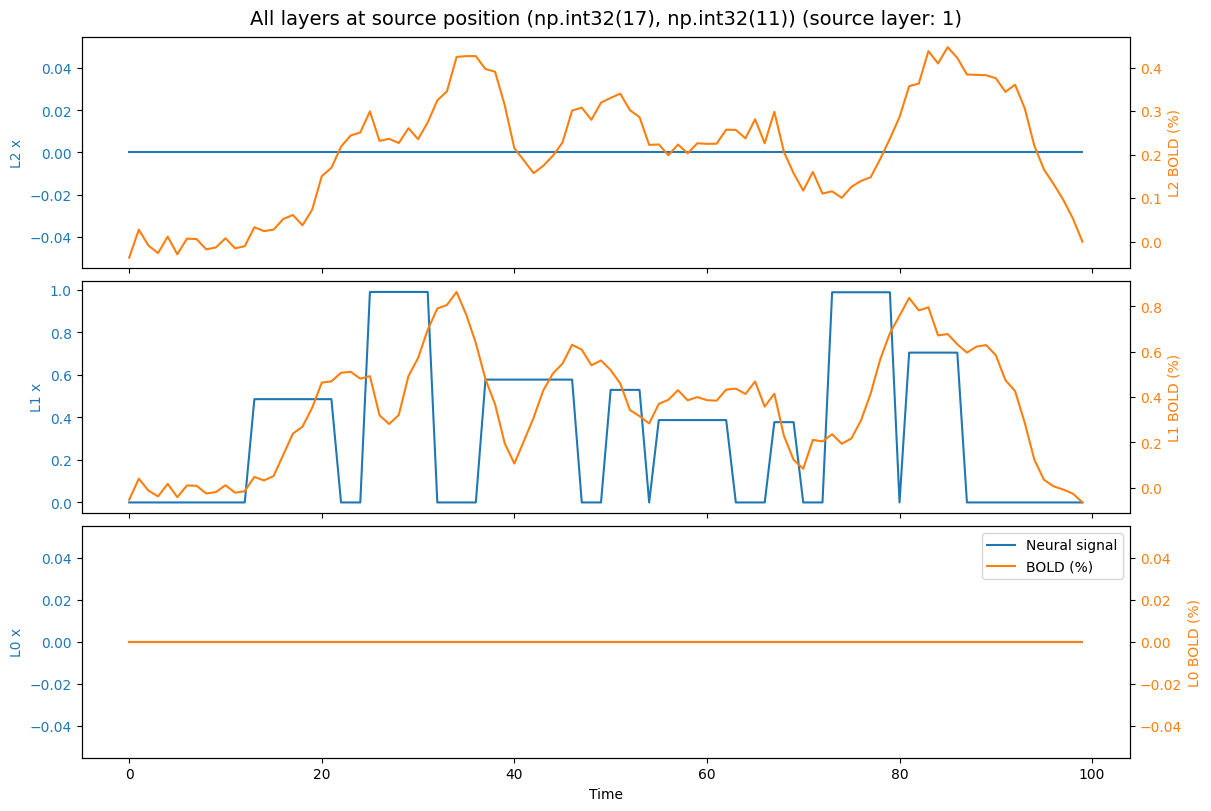

In [128]:
data_idx = np.random.randint(0, bold.shape[0])
slayer = source_location[data_idx]
spos = source_pos[data_idx]
print(f"Source layer: {slayer}, Source position: {spos}")

n_layers = x.shape[1]

fig, ax = plt.subplots(nrows=n_layers, ncols=1, figsize=(12, 8), sharex=True, constrained_layout=True)

for i in range(n_layers):
    # superficial at top, deep at bottom
    row = n_layers - 1 - i

    x_sig = x[data_idx, i, :, *spos]
    bold_sig = bold[data_idx, i, :, *spos]

    l1, = ax[row].plot(x_sig, color="tab:blue", label="Neural signal")
    ax[row].set_ylabel(f"L{i} x", color="tab:blue")
    ax[row].tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax[row].twinx()
    l2, = ax2.plot(bold_sig * 100, color="tab:orange", label="BOLD (%)")
    ax2.set_ylabel(f"L{i} BOLD (%)", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    if i == 0:
        ax[row].legend(handles=[l1, l2], loc="upper right")

ax[-1].set_xlabel("Time")
fig.suptitle(f"All layers at source position {tuple(spos)} (source layer: {slayer})", fontsize=14)
plt.show()


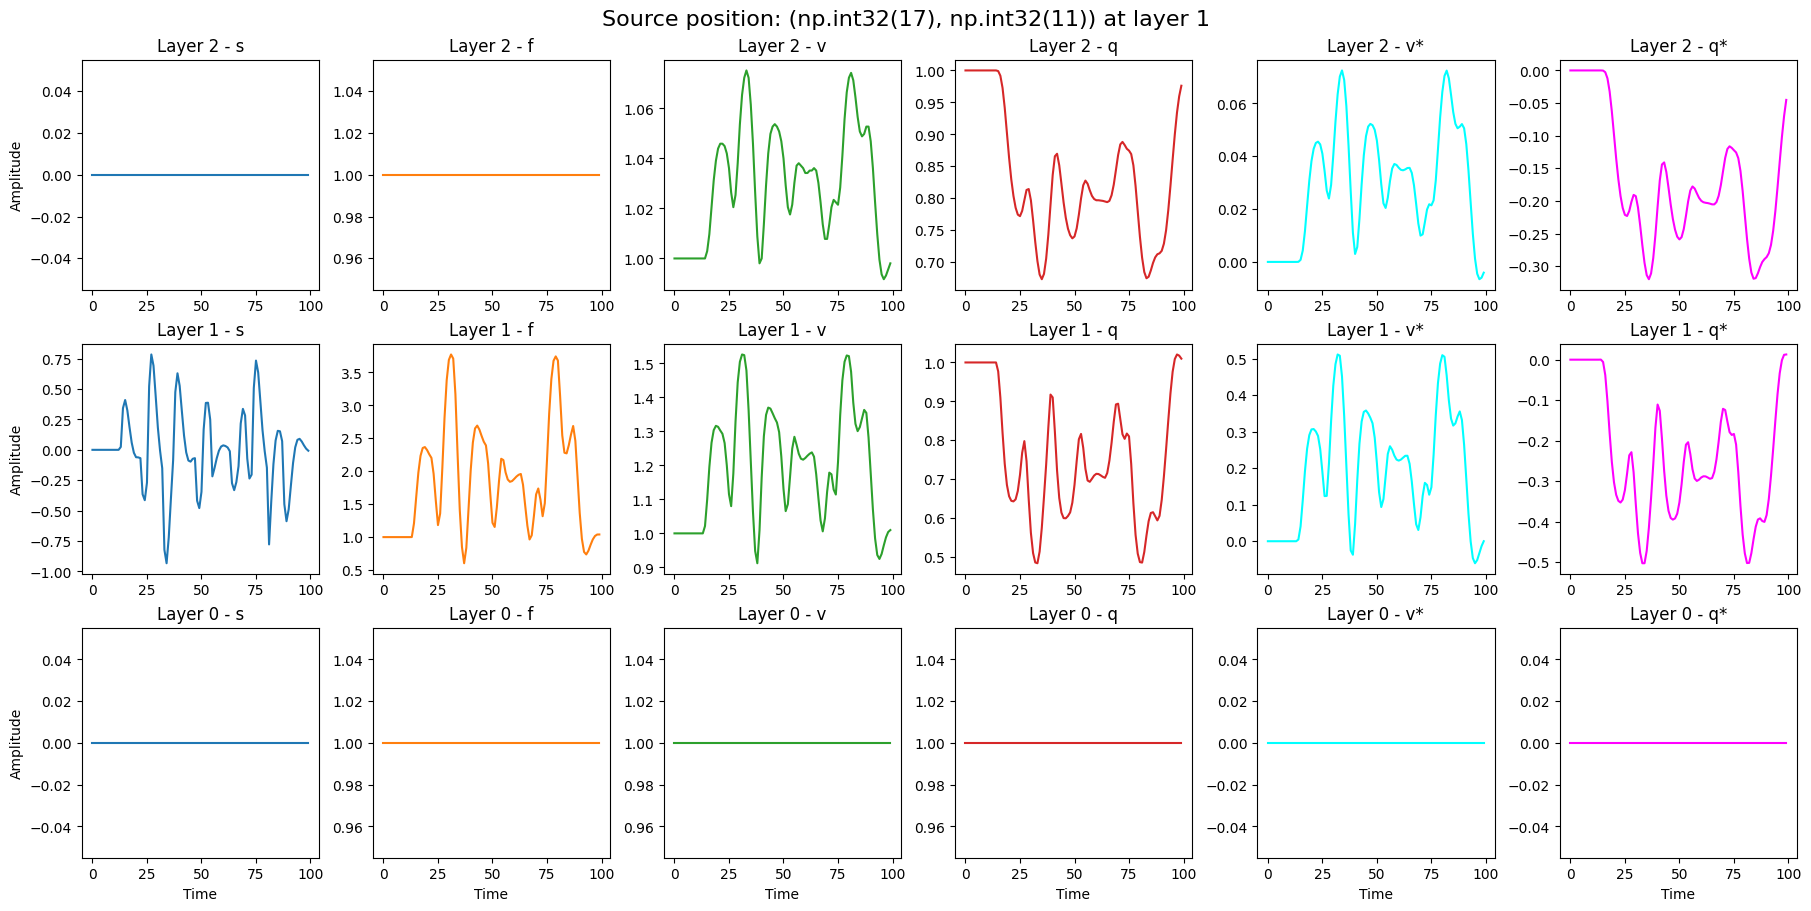

In [129]:
fig, ax = plt.subplots(nrows=3, ncols=6, figsize=(18, 9), constrained_layout=True)

n_layers = s.shape[1]  # expected 3

for i in range(n_layers):
    row = n_layers - 1 - i  # deepest at bottom

    ax[row, 0].plot(s[data_idx, i, :, *spos], color="tab:blue")
    ax[row, 0].set_title(f"Layer {i} - s")

    ax[row, 1].plot(f[data_idx, i, :, *spos], color="tab:orange")
    ax[row, 1].set_title(f"Layer {i} - f")

    ax[row, 2].plot(v[data_idx, i, :, *spos], color="tab:green")
    ax[row, 2].set_title(f"Layer {i} - v")

    ax[row, 3].plot(q[data_idx, i, :, *spos], color="tab:red")
    ax[row, 3].set_title(f"Layer {i} - q")

    ax[row, 4].plot(v_star[data_idx, i, :, *spos], color="cyan")
    ax[row, 4].set_title(f"Layer {i} - v*")

    ax[row, 5].plot(q_star[data_idx, i, :, *spos], color="magenta")
    ax[row, 5].set_title(f"Layer {i} - q*")

for r in range(n_layers):
    ax[r, 0].set_ylabel("Amplitude")
for c in range(6):
    ax[-1, c].set_xlabel("Time")

plt.suptitle(f"Source position: {tuple(spos)} at layer {slayer}", fontsize=16)
plt.show()
